In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DBSCAN_OUT_ROOT = Path("/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset")
SUMMARY_DIR = DBSCAN_OUT_ROOT / "Summary"

FRAME_SUMMARY_PATH = SUMMARY_DIR / "dbscan_frame_summary_global.csv"

POINT_COUNT_COL = "main_cluster_points"
STATUS_COL = "status"

print("DBSCAN root:", DBSCAN_OUT_ROOT)
print("Frame summary:", FRAME_SUMMARY_PATH)
print("Exists:", FRAME_SUMMARY_PATH.exists())

DBSCAN root: /media/spell/Spell-lab/Lidar/D.DBSCAN Dataset
Frame summary: /media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/Summary/dbscan_frame_summary_global.csv
Exists: True


In [21]:
if not FRAME_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"File summary tidak ditemukan: {FRAME_SUMMARY_PATH}\n"
        "Pastikan proses apply DBSCAN sudah selesai dan Cell merge summary sudah dijalankan."
    )

df = pd.read_csv(FRAME_SUMMARY_PATH)

print("Shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Shape: (47371, 27)


/tmp/ipykernel_724019/2944887094.py:7: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FRAME_SUMMARY_PATH)


,frame_id,timestamp_min,timestamp_max,n_raw_frame,n_before_cleaning,n_after_finite,n_after_corr_zero,n_after_raw_zero,n_removed_non_finite,n_removed_corr_zero,...,main_cluster_label,main_cluster_points,main_cluster_ratio_clean,dataset,room,activity,subject,file_id,file_name,summary_file
0,0,6359557692940,6359640732940,629,629,629,449,449,0,180,...,0,426,0.948775,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
1,1,6359657532940,6359745372940,627,627,627,451,451,0,176,...,0,436,0.966741,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
2,2,6359762652940,6359844732940,616,616,616,452,452,0,164,...,0,428,0.946903,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
3,3,6359862012940,6359949852940,602,602,602,440,440,0,162,...,0,428,0.972727,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
4,4,6359967132940,6360049212940,633,633,633,458,458,0,175,...,0,430,0.938865,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...


['frame_id', 'timestamp_min', 'timestamp_max', 'n_raw_frame', 'n_before_cleaning', 'n_after_finite', 'n_after_corr_zero', 'n_after_raw_zero', 'n_removed_non_finite', 'n_removed_corr_zero', 'n_removed_raw_zero', 'n_after_cleaning', 'status', 'n_clusters_total', 'n_valid_clusters', 'n_noise', 'noise_ratio', 'main_cluster_label', 'main_cluster_points', 'main_cluster_ratio_clean', 'dataset', 'room', 'activity', 'subject', 'file_id', 'file_name', 'summary_file']


In [22]:
valid_df = df[df[STATUS_COL] == "valid"].copy()

valid_df[POINT_COUNT_COL] = pd.to_numeric(
    valid_df[POINT_COUNT_COL],
    errors="coerce"
)

valid_df = valid_df.dropna(subset=[POINT_COUNT_COL]).copy()
valid_df[POINT_COUNT_COL] = valid_df[POINT_COUNT_COL].astype(int)

print("Total frames:", len(df))
print("Valid frames:", len(valid_df))
print("Invalid frames:", len(df) - len(valid_df))
print("Valid ratio:", len(valid_df) / len(df))

display(valid_df.head())

Total frames: 47371
Valid frames: 47371
Invalid frames: 0
Valid ratio: 1.0


,frame_id,timestamp_min,timestamp_max,n_raw_frame,n_before_cleaning,n_after_finite,n_after_corr_zero,n_after_raw_zero,n_removed_non_finite,n_removed_corr_zero,...,main_cluster_label,main_cluster_points,main_cluster_ratio_clean,dataset,room,activity,subject,file_id,file_name,summary_file
0,0,6359557692940,6359640732940,629,629,629,449,449,0,180,...,0,426,0.948775,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
1,1,6359657532940,6359745372940,627,627,627,451,451,0,176,...,0,436,0.966741,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
2,2,6359762652940,6359844732940,616,616,616,452,452,0,164,...,0,428,0.946903,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
3,3,6359862012940,6359949852940,602,602,602,440,440,0,162,...,0,428,0.972727,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...
4,4,6359967132940,6360049212940,633,633,633,458,458,0,175,...,0,430,0.938865,testing,Uncontrolled Room,Jongkok,Kanaya,4,4.csv,/media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/...


In [23]:
point_counts = valid_df[POINT_COUNT_COL]

global_stats = {
    "n_valid_frames": len(point_counts),
    "min": point_counts.min(),
    "max": point_counts.max(),
    "mean": point_counts.mean(),
    "std": point_counts.std(),
    "p01": point_counts.quantile(0.01),
    "p05": point_counts.quantile(0.05),
    "p10": point_counts.quantile(0.10),
    "p25": point_counts.quantile(0.25),
    "p50_median": point_counts.quantile(0.50),
    "p75": point_counts.quantile(0.75),
    "p90": point_counts.quantile(0.90),
    "p95": point_counts.quantile(0.95),
    "p99": point_counts.quantile(0.99),
}

global_stats_df = pd.DataFrame([global_stats])

display(global_stats_df)

global_stats_path = SUMMARY_DIR / "point_count_distribution_global.csv"
global_stats_df.to_csv(global_stats_path, index=False)

print("Saved:", global_stats_path)

,n_valid_frames,min,max,mean,std,p01,p05,p10,p25,p50_median,p75,p90,p95,p99
0,47371,40,1666,433.819869,267.372343,101.0,141.0,160.0,230.0,369.0,559.0,804.0,1002.0,1282.0


Saved: /media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/Summary/point_count_distribution_global.csv


In [24]:
group_cols = ["dataset", "room", "activity"]

group_stats_df = (
    valid_df
    .groupby(group_cols, dropna=False)[POINT_COUNT_COL]
    .agg(
        n_frames="count",
        min_points="min",
        mean_points="mean",
        median_points="median",
        std_points="std",
        p05=lambda x: x.quantile(0.05),
        p10=lambda x: x.quantile(0.10),
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        max_points="max",
    )
    .reset_index()
)

display(group_stats_df)

group_stats_path = SUMMARY_DIR / "point_count_distribution_by_group.csv"
group_stats_df.to_csv(group_stats_path, index=False)

print("Saved:", group_stats_path)

,dataset,room,activity,n_frames,min_points,mean_points,median_points,std_points,p05,p10,p25,p75,p90,p95,max_points
0,development,NaN,Bungkuk,6507,40,447.228062,393.0,280.907368,129.0,146.0,213.0,617.50,804.0,1001.70,1666
1,development,NaN,Duduk,6409,64,498.375566,452.0,295.315203,150.0,167.0,223.0,661.00,950.2,1067.00,1504
2,development,NaN,Jatuh,6929,84,397.966806,303.0,260.386597,169.0,191.0,233.0,461.00,801.6,1027.00,1553
3,development,NaN,Jongkok,6645,70,412.182242,373.0,259.716606,121.2,140.0,212.0,515.00,745.6,903.60,1497
4,testing,Controlled Room,Bungkuk,2637,62,427.263178,369.0,256.445619,127.0,145.0,191.0,607.00,771.4,880.40,1411
5,testing,Controlled Room,Duduk,2670,58,462.434831,427.0,268.653784,154.0,161.0,226.0,621.00,800.2,992.55,1451
6,testing,Controlled Room,Jatuh,2861,67,394.757427,299.0,250.463499,161.0,185.0,227.0,479.00,808.0,1025.00,1288
7,testing,Controlled Room,Jongkok,2690,66,391.083643,364.0,236.435961,136.0,145.0,205.0,470.75,719.2,863.65,1493
8,testing,Uncontrolled Room,Bungkuk,2442,71,436.750205,373.0,250.622925,148.0,160.0,248.0,582.00,754.0,929.90,1418
9,testing,Uncontrolled Room,Duduk,2486,77,483.345133,437.0,257.628611,157.0,173.0,298.0,615.00,808.0,978.75,1434


Saved: /media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/Summary/point_count_distribution_by_group.csv


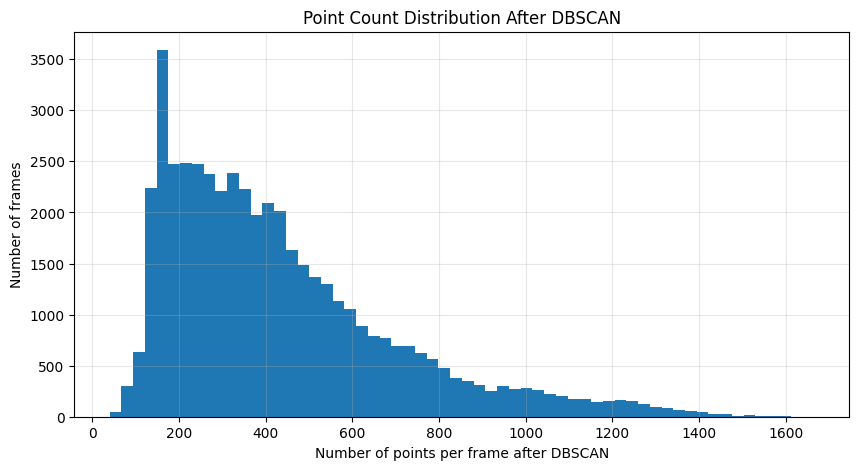

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(point_counts, bins=60)
plt.xlabel("Number of points per frame after DBSCAN")
plt.ylabel("Number of frames")
plt.title("Point Count Distribution After DBSCAN")
plt.grid(True, alpha=0.3)
plt.show()

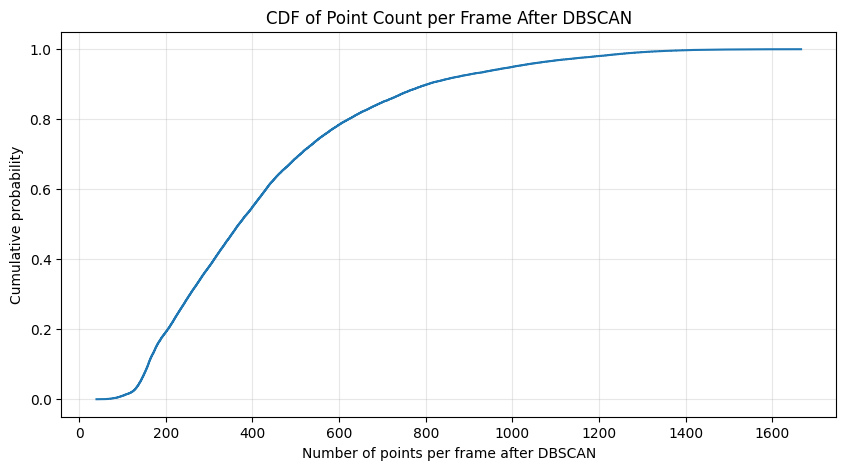

In [26]:
sorted_counts = np.sort(point_counts.to_numpy())
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

plt.figure(figsize=(10, 5))
plt.plot(sorted_counts, cdf)
plt.xlabel("Number of points per frame after DBSCAN")
plt.ylabel("Cumulative probability")
plt.title("CDF of Point Count per Frame After DBSCAN")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
N_CANDIDATES = [
    64, 96, 128, 160, 192, 224, 256, 320, 369, 384, 433,  512,
    576, 640, 704, 768, 832, 896, 960, 1000
]

candidate_rows = []

for n in N_CANDIDATES:
    below = (point_counts < n).sum()
    equal_or_above = (point_counts >= n).sum()
    
    candidate_rows.append({
        "N_target": n,
        "frames_need_upsampling": below,
        "frames_need_downsampling": equal_or_above,
        "upsampling_ratio": below / len(point_counts),
        "downsampling_ratio": equal_or_above / len(point_counts),
        "coverage_ratio_points_ge_N": equal_or_above / len(point_counts),
    })

candidate_df = pd.DataFrame(candidate_rows)

display(candidate_df)

candidate_path = SUMMARY_DIR / "fixed_N_candidate_analysis.csv"
candidate_df.to_csv(candidate_path, index=False)

print("Saved:", candidate_path)

,N_target,frames_need_upsampling,frames_need_downsampling,upsampling_ratio,downsampling_ratio,coverage_ratio_points_ge_N
0,64,29,47342,0.000612,0.999388,0.999388
1,96,363,47008,0.007663,0.992337,0.992337
2,128,1256,46115,0.026514,0.973486,0.973486
3,160,4711,42660,0.099449,0.900551,0.900551
4,192,8418,38953,0.177704,0.822296,0.822296
5,224,11219,36152,0.236833,0.763167,0.763167
6,256,14162,33209,0.298959,0.701041,0.701041
7,320,19610,27761,0.413966,0.586034,0.586034
8,369,23673,23698,0.499736,0.500264,0.500264
9,384,24816,22555,0.523865,0.476135,0.476135


Saved: /media/spell/Spell-lab/Lidar/D.DBSCAN Dataset/Summary/fixed_N_candidate_analysis.csv


In [28]:
print("===== RECOMMENDATION GUIDE =====")
print("Gunakan ini sebagai bantuan awal, bukan keputusan final otomatis.\n")

p10 = point_counts.quantile(0.10)
p25 = point_counts.quantile(0.25)
p50 = point_counts.quantile(0.50)

print(f"P10  : {p10:.2f}")
print(f"P25  : {p25:.2f}")
print(f"P50  : {p50:.2f}")
print(f"Mean : {point_counts.mean():.2f}")

recommended_candidates = candidate_df[
    candidate_df["upsampling_ratio"] <= 0.25
].copy()

display(recommended_candidates)

if len(recommended_candidates) > 0:
    print("Kandidat yang relatif aman jika ingin upsampling <= 25% frame:")
    print(recommended_candidates["N_target"].tolist())
else:
    print("Tidak ada kandidat pada list yang memenuhi upsampling <= 25%.")

===== RECOMMENDATION GUIDE =====
Gunakan ini sebagai bantuan awal, bukan keputusan final otomatis.

P10  : 160.00
P25  : 230.00
P50  : 369.00
Mean : 433.82


,N_target,frames_need_upsampling,frames_need_downsampling,upsampling_ratio,downsampling_ratio,coverage_ratio_points_ge_N
0,64,29,47342,0.000612,0.999388,0.999388
1,96,363,47008,0.007663,0.992337,0.992337
2,128,1256,46115,0.026514,0.973486,0.973486
3,160,4711,42660,0.099449,0.900551,0.900551
4,192,8418,38953,0.177704,0.822296,0.822296
5,224,11219,36152,0.236833,0.763167,0.763167


Kandidat yang relatif aman jika ingin upsampling <= 25% frame:
[64, 96, 128, 160, 192, 224]
